In [1]:
print("Hello")

Hello


In [2]:
!pip install pandas scikit-learn

In [3]:
import pandas as pd
df =pd.read_csv(r"C:\Users\ArifAmeerJohn\Downloads\Cancer_Prediction.csv")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [7]:

X = df.drop(columns='diagnosis')
y = df['diagnosis']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           B       0.95      0.99      0.97        71
           M       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [8]:

import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [9]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

In [12]:
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9473684210526315


In [19]:
dt = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 94.74


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [26]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [31]:
df1 = df[['radius_mean', 'texture_mean', 'perimeter_mean']]

df1

,radius_mean,texture_mean,perimeter_mean
0,17.99,10.38,122.80
1,20.57,17.77,132.90
2,19.69,21.25,130.00
3,11.42,20.38,77.58
4,20.29,14.34,135.10
...,...,...,...
564,21.56,22.39,142.00
565,20.13,28.25,131.20
566,16.60,28.08,108.30
567,20.60,29.33,140.10


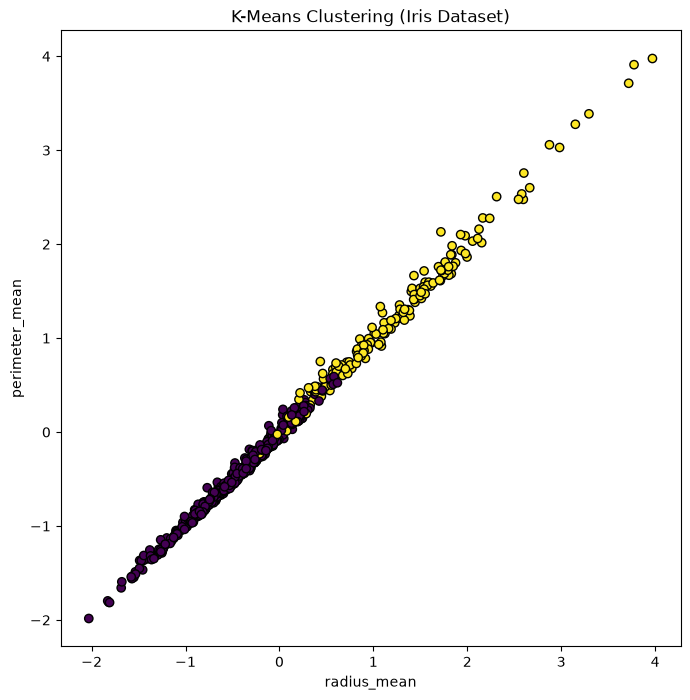

Centroids of clusters:
[[-0.51467871 -0.27525334 -0.51667853]
 [ 1.27100536  0.67974148  1.27594394]]

Inertia: 853.2078980595458

Data with cluster assignments:
   radius_mean  texture_mean  perimeter_mean
0        17.99         10.38          122.80
1        20.57         17.77          132.90
2        19.69         21.25          130.00
3        11.42         20.38           77.58
4        20.29         14.34          135.10


In [35]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df1)
# K-Means clustering
kmeans = KMeans(n_clusters=2)
kmeans.fit(df_scaled)

# Add the predicted clusters to the DataFrame
df['Cluster'] = kmeans.labels_

# Visualize the clusters with a scatter plot (using only two dimensions for visualization)
plt.figure(figsize=(8, 8))
plt.scatter(df_scaled[:, 0], df_scaled[:, 2], c=kmeans.labels_, cmap='viridis', marker='o', edgecolor='k')
plt.title('K-Means Clustering (Iris Dataset)')
plt.xlabel(df1.columns[0])
plt.ylabel(df1.columns[2])
plt.show()

# Print centroids and inertia
print("Centroids of clusters:")
print(kmeans.cluster_centers_)
print("\nInertia:", kmeans.inertia_)

# Show first few rows of data with cluster assignment
print("\nData with cluster assignments:")
print(df1.head())

In [36]:
spam_data = pd.read_csv(r"C:\Users\ArifAmeerJohn\Downloads\spam_ham_dataset.csv")

In [44]:
features = spam_data['message']
features.drop_duplicates(inplace=True)

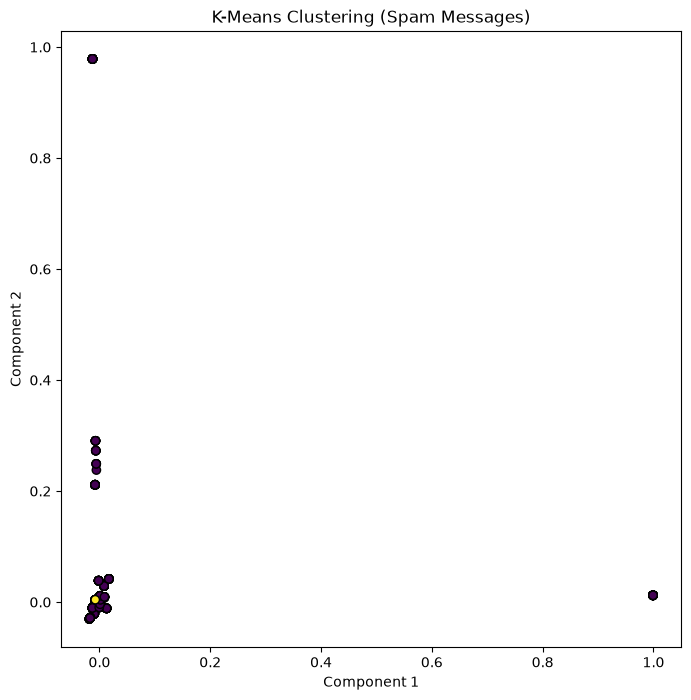

Inertia: 357.3624244415112
                                               message  Cluster
0    Happy birthday! Wishing you a wonderful year a...        0
1            Thank you for attending today's workshop.        0
2            Thank you for attending today's workshop.        0
3    Exclusive deal on smartwatch. Hurry before sto...        0
4            You have received a bonus reward of $614.        0
..                                                 ...      ...
395  You are selected for a free vacation to Dubai....        0
396  Exclusive deal on laptop. Hurry before stock r...        0
397    Reminder: submit your assignment before Friday.        1
398        Let's schedule a meeting tomorrow at 10 AM.        0
399  Limited time offer! Buy headphones at 90% disc...        0

[400 rows x 2 columns]


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(spam_data['message'])

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

spam_data['Cluster'] = kmeans.labels_

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

plt.figure(figsize=(8, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans.labels_, cmap='viridis', marker='o', edgecolor='k')
plt.title('K-Means Clustering (Spam Messages)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

print("Inertia:", kmeans.inertia_)
print(spam_data[['message', 'Cluster']])

In [50]:
#export as csv
spam_data.to_csv(r"C:\Users\ArifAmeerJohn\Downloads\spam_ham_dataset_with_clusters.csv", index=False)

In [51]:
%pip install sentence_transformers

  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 596.4/596.4 kB 4.6 MB/s  0:00:00
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.6 MB 5.3 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/11.6 MB 4.7 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/11.6 MB 4.8 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.6 MB 4.9 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.6 MB 4.9 MB/s eta 0:00:02
   -------------------- ------------------- 6.0/11.6 MB 5.0 MB/s eta 0:00:02
   ------------------------ --------------- 7.1/11.6 MB 5.0 MB/s eta 0:00:01
   -------------------------- ------------- 7.6/11.6 MB 4.9 MB/s eta 0:00:01
   --------------------------- ------------ 8.1/11.6 MB 4.7 MB/s eta 0:00:01
   ------------------

Batches: 100%|██████████| 13/13 [00:00<00:00, 14.30it/s]


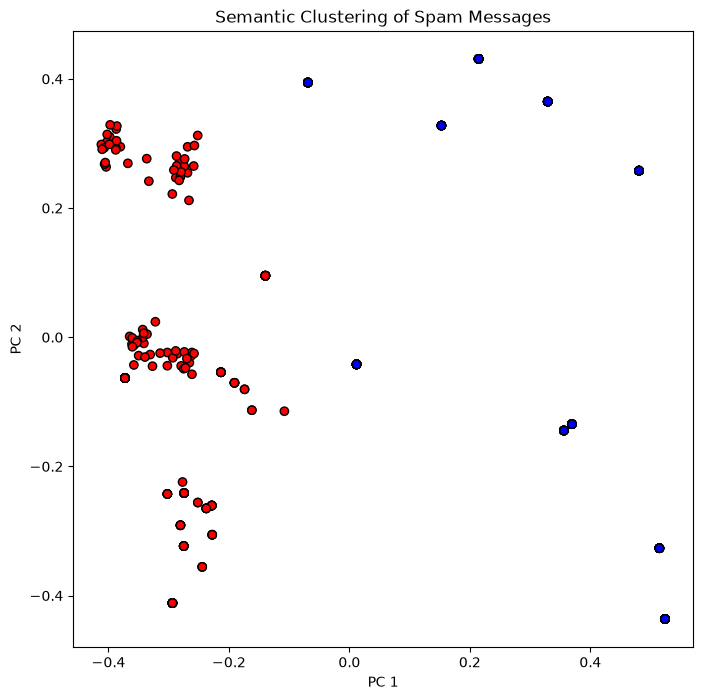

                                             message  Cluster
0  Happy birthday! Wishing you a wonderful year a...        1
1          Thank you for attending today's workshop.        1
2          Thank you for attending today's workshop.        1
3  Exclusive deal on smartwatch. Hurry before sto...        0
4          You have received a bonus reward of $614.        0


In [57]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(spam_data['message'].tolist(), show_progress_bar=True)

kmeans = KMeans(n_clusters=2, random_state=42)
spam_data['Cluster'] = kmeans.fit_predict(embeddings)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(embeddings)
color=spam_data['Cluster'].map({0: 'red', 1: 'blue'})
plt.figure(figsize=(8, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=color, marker='o', edgecolor='k')
plt.title('Semantic Clustering of Spam Messages')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

print(spam_data[['message', 'Cluster']].head())

In [56]:
#export as csv
spam_data.to_csv(r"C:\Users\ArifAmeerJohn\Downloads\spam_ham_dataset_with_clusters1.csv", index=False)

In [58]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [67]:
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    cross_val_score
)
df = pd.read_csv(r"C:\Users\ArifAmeerJohn\Downloads\Cancer_Prediction.csv")
mv = df.isnull().sum()
df = df.drop(columns=['Unnamed: 32'])

In [68]:
from sklearn.linear_model import LogisticRegression

# 1. LOAD DATASET
X = df.drop(columns='diagnosis')
y = df['diagnosis']

print("Dataset Info")
print("Shape:", X.shape)
print("Classes:", np.unique(y))
print("\n" + "="*50)

Dataset Info
Shape: (569, 31)
Classes: ['B' 'M']



In [69]:
# 2. TRAIN-TEST SPLIT (BASELINE)

print("\n1. TRAIN-TEST SPLIT (BASELINE)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

tt_accuracy = model.score(X_test, y_test)

print("Accuracy:", round(tt_accuracy, 4))
print("\n" + "="*50)


1. TRAIN-TEST SPLIT (BASELINE)
Accuracy: 0.9561



In [71]:
# 3. INSTABILITY DEMO

print("\n2. INSTABILITY OF TRAIN-TEST SPLIT")


for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"Run {i+1}: Accuracy = {round(acc, 4)}")

print("\n" + "="*50)


2. INSTABILITY OF TRAIN-TEST SPLIT
Run 1: Accuracy = 0.9123
Run 2: Accuracy = 0.9035
Run 3: Accuracy = 0.9211
Run 4: Accuracy = 0.9474
Run 5: Accuracy = 0.9561



In [72]:
# 4. K-FOLD CROSS VALIDATION
print("\n3. K-FOLD CROSS VALIDATION")


kf = KFold(n_splits=5, shuffle=True, random_state=42)

kf_scores = cross_val_score(model, X, y, cv=kf)

print("Scores:", np.round(kf_scores, 4))
print("Mean Accuracy:", round(kf_scores.mean(), 4))

print("\n" + "="*50)



3. K-FOLD CROSS VALIDATION
Scores: [0.9561 0.9649 0.8684 0.9123 0.8938]
Mean Accuracy: 0.9191



In [73]:
# 5. STRATIFIED K-FOLD

print("\n4. STRATIFIED K-FOLD")
print("---------------------")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

skf_scores = cross_val_score(model, X, y, cv=skf)

print("Scores:", np.round(skf_scores, 4))
print("Mean Accuracy:", round(skf_scores.mean(), 4))

print("\n" + "="*50)



4. STRATIFIED K-FOLD
---------------------
Scores: [0.9211 0.9123 0.8947 0.9649 0.9469]
Mean Accuracy: 0.928



In [75]:
# 7. FINAL COMPARISON
print("\n6. FINAL COMPARISON")
print("--------------------")

results = {
    "Train-Test Split": tt_accuracy,
    "K-Fold (5)": kf_scores.mean(),
    "Stratified K-Fold (5)": skf_scores.mean(),
}

for method, score in results.items():
    print(f"{method:<25} : {round(score, 4)}")

print("\n" + "="*50)


6. FINAL COMPARISON
--------------------
Train-Test Split          : 0.9561
K-Fold (5)                : 0.9191
Stratified K-Fold (5)     : 0.928



In [79]:
# CROSS VALIDATION FOR REGRESSION - FULL DEMO


import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# 1. LOAD DATASET

df = pd.read_csv(r"C:\Users\ArifAmeerJohn\Downloads\kc_house_data.csv")
df = df.dropna()
X = df.drop(columns=['price','id','date'])
y = df['price']
print("\nDataset Info")
print("Shape:", X.shape)
print("\n" + "="*50)


Dataset Info
Shape: (21611, 18)



In [80]:
# 2. TRAIN-TEST SPLIT (BASELINE)

print("\n1. TRAIN-TEST SPLIT (BASELINE)")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

baseline_r2 = model.score(X_test, y_test)

print("R2 Score (Baseline):", round(baseline_r2, 4))
print("\n" + "="*50)


1. TRAIN-TEST SPLIT (BASELINE)
R2 Score (Baseline): 0.7092



In [81]:
# 3. INSTABILITY DEMO
print("\n2. INSTABILITY OF TRAIN-TEST SPLIT")


for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model.fit(X_train, y_train)
    r2 = model.score(X_test, y_test)
    print(f"Run {i+1}: R2 = {round(r2, 4)}")

print("\n" + "="*50)


2. INSTABILITY OF TRAIN-TEST SPLIT
Run 1: R2 = 0.6984
Run 2: R2 = 0.704
Run 3: R2 = 0.6896
Run 4: R2 = 0.6945
Run 5: R2 = 0.7016



In [82]:

# 4. K-FOLD CROSS VALIDATION (R2)

print("\n3. K-FOLD CROSS VALIDATION (R2)")


kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("R2 Scores:", np.round(r2_scores, 4))
print("Mean R2:", round(r2_scores.mean(), 4))

print("\n" + "="*50)


3. K-FOLD CROSS VALIDATION (R2)
R2 Scores: [0.7092 0.6961 0.6862 0.698  0.6941]
Mean R2: 0.6967



In [83]:
# 5. CROSS VALIDATION WITH MSE & RMSE

print("\n4. CROSS VALIDATION (MSE & RMSE)")


mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

rmse_scores = np.sqrt(-mse_scores)

print("RMSE Scores:", np.round(rmse_scores, 4))
print("Mean RMSE:", round(rmse_scores.mean(), 4))

print("\n" + "="*50)


4. CROSS VALIDATION (MSE & RMSE)
RMSE Scores: [208435.6483 224868.6973 193865.3805 188280.1392 192073.6823]
Mean RMSE: 201504.7095



In [84]:
# 6. SINGLE MODEL ASSESSMENT

print("\n5. SINGLE MODEL EVALUATION")


print("Mean R2:", round(r2_scores.mean(), 4))
print("Std Dev:", round(r2_scores.std(), 4))

print("\n" + "="*50)


5. SINGLE MODEL EVALUATION
Mean R2: 0.6967
Std Dev: 0.0074



In [85]:
# 7. COMPARING TWO MODELS

print("\n6. MODEL COMPARISON")


model1 = LinearRegression()
model2 = DecisionTreeRegressor()

r2_1 = cross_val_score(model1, X, y, cv=kf, scoring='r2')
r2_2 = cross_val_score(model2, X, y, cv=kf, scoring='r2')

print("Linear Regression Mean R2:", round(r2_1.mean(), 4))
print("Decision Tree Mean R2:", round(r2_2.mean(), 4))

print("\n" + "="*50)


6. MODEL COMPARISON
Linear Regression Mean R2: 0.6967
Decision Tree Mean R2: 0.7391



In [86]:
# 7. COMPARING TWO MODELS

print("\n6. MODEL COMPARISON")


model1 = LinearRegression()
model2 = DecisionTreeRegressor()

r2_1 = cross_val_score(model1, X, y, cv=kf, scoring='r2')
r2_2 = cross_val_score(model2, X, y, cv=kf, scoring='r2')

print("Linear Regression Mean R2:", round(r2_1.mean(), 4))
print("Decision Tree Mean R2:", round(r2_2.mean(), 4))

print("\n" + "="*50)


6. MODEL COMPARISON
Linear Regression Mean R2: 0.6967
Decision Tree Mean R2: 0.7454



In [33]:
"""Task 1: Intelligent Data Cleaning Pipeline
Build a reusable function called:
clean_zomato(df)

The function should:
Remove duplicates
Handle missing values differently based on datatype
Convert Yes/No columns to binary
Rename all columns to title_case
Remove unnecessary spaces
Correct inconsistent text (e.g., uppercase/lowercase)
Remove impossible values (negative costs, invalid ratings)
The function should work on any future Zomato dataset."""

# Read with different encoding to handle the error
zomato_data = pd.read_csv(r"C:\Users\ArifAmeerJohn\Downloads\zomato.csv", encoding='latin-1')
zomato_data.head()
def clean_zomato(df):
    df = df.drop_duplicates()   
    for col in df.select_dtypes(include='str').columns:
        df[col] = df[col].str.lower()

    df.columns = [col.title() for col in df.columns]
    
    for col in df.select_dtypes(include='str').columns:
        df[col] = df[col].str.strip()
    #Correct inconsistent text (e.g., uppercase/lowercase)
    for col in df.select_dtypes(include='str').columns:
        df[col] = df[col].str.strip().str.title()
    #Remove unnecessary spaces
    for col in df.select_dtypes(include='str').columns:
        df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
    
    if 'Average Cost for two' in df.columns:
        df = df[df['Average Cost for two'] >= 0]
    if 'Aggregate rating' in df.columns:
        df = df[(df['Aggregate rating'] >= 0) & (df['Aggregate rating'] <= 5)]
    #Handle missing values differently based on datatype
    for col in df.columns:
        if df[col].dtype == 'str':
            df[col] = df[col].fillna('Unknown')
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    #Convert Yes/No columns to binary 
    for col in df.select_dtypes(include='str').columns:
        if df[col].nunique() == 2 and set(df[col].unique()) == {'Yes', 'No'}:
            df[col] = df[col].map({'Yes': 1, 'No': 0})

    return df
zomato_data = clean_zomato(zomato_data)
zomato_data.head()



,Restaurant Id,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table Booking,Has Online Delivery,Is Delivering Now,Switch To Order Menu,Price Range,Aggregate Rating,Rating Color,Rating Text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),1,0,0,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),1,0,0,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),1,0,0,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, Sm Megamall, O...","Sm Megamall, Ortigas, Mandaluyong City","Sm Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),0,0,0,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, Sm Megamall, Ortigas...","Sm Megamall, Ortigas, Mandaluyong City","Sm Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),1,0,0,No,4,4.8,Dark Green,Excellent,229


In [30]:
"""Task 2: Restaurant Popularity Index
Create a new feature called

Popularity Score using

Aggregate Rating
Votes
Table Booking
Online Delivery"""

zomato_data['Popularity Score'] = (
    0.5 * (zomato_data['Aggregate Rating'] / 5) +
    0.3 * (zomato_data['Votes'] / zomato_data['Votes'].max()) +
    0.1 * zomato_data['Has Table Booking'] +
    0.1 * zomato_data['Has Online Delivery']
) * 100
zomato_data.head()


,Restaurant Id,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table Booking,Has Online Delivery,Is Delivering Now,Switch To Order Menu,Price Range,Aggregate Rating,Rating Color,Rating Text,Votes,Popularity Score
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,1,0,0,No,3,4.8,Dark Green,Excellent,314,58.861533
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,1,0,0,No,3,4.5,Dark Green,Excellent,591,56.621547
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,1,0,0,No,4,4.4,Green,Very Good,270,54.740808
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, Sm Megamall, O...","Sm Megamall, Ortigas, Mandaluyong City","Sm Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,0,0,0,No,4,4.9,Dark Green,Excellent,365,50.001463
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, Sm Megamall, Ortigas...","Sm Megamall, Ortigas, Mandaluyong City","Sm Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,1,0,0,No,4,4.8,Dark Green,Excellent,229,58.628315


In [4]:
"""Task 3:
Exploratory Data Analysis Dashboard
Which city has the highest average rating?
Which city has the highest average restaurant cost?
Which cuisine receives the highest ratings?
Does online delivery improve ratings?

use necessary visualization"""

import pandas as pd
import matplotlib.pyplot as plt
city_rating = zomato_data.groupby('City')['Aggregate Rating'].mean().sort_values(ascending=False).head(5)

print("City with Highest Average Rating:")
print(city_rating.head(5))
print()

plt.figure(figsize=(12,6))
city_rating.plot(kind='bar', color='skyblue')
plt.title("Average Restaurant Rating by City")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


city_cost = zomato_data.groupby('City')['Price Range'].mean().sort_values(ascending=False).head(5)

print("City with Highest Average Restaurant Cost:")
print(city_cost.head(1))
print()

plt.figure(figsize=(12,6))
city_cost.plot(kind='bar', color='orange')
plt.title("Average Restaurant Cost (Price Range) by City")
plt.xlabel("City")
plt.ylabel("Average Price Range")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



"""cuisine_rating = zomato_data.groupby('Cuisines')['Aggregate Rating'].mean().sort_values(ascending=False).head(5)

print("Cuisine with Highest Average Rating:")
print(cuisine_rating.head(10))
print()

plt.figure(figsize=(12,6))
cuisine_rating.head(10).plot(kind='bar', color='green')
plt.title("Top 10 Highest Rated Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()"""


delivery_rating = zomato_data.groupby('Has Online Delivery')['Aggregate Rating'].mean()

print("Average Rating based on Online Delivery:")
print(delivery_rating)
print()

plt.figure(figsize=(6,5))
delivery_rating.plot(kind='bar', color=['red','blue'])
plt.title("Average Rating vs Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
cuisine_df = zomato_data.copy()

cuisine_df['Cuisines'] = cuisine_df['Cuisines'].str.split(',')


cuisine_df = cuisine_df.explode('Cuisines')


cuisine_df['Cuisines'] = cuisine_df['Cuisines'].str.strip()
cuisine_rating = (
    cuisine_df.groupby('Cuisines')['Aggregate Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(cuisine_rating)

plt.figure(figsize=(12,6))

cuisine_rating.plot(kind='bar', color='green')

plt.title("Top 10 Highest Rated Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
cuisine_df

KeyError: 'Column not found: Aggregate Rating'

In [16]:
"""Task 4:
Identify outliers using two IQR method:
IQR
Then create two datasets:"""

import pandas as pd
import numpy as np
zomato_data = pd.read_csv(r"C:\Users\ArifAmeerJohn\Downloads\zomato.csv", encoding='latin-1')
numeric_cols = zomato_data.select_dtypes(include=np.number).columns




In [4]:
# Dataset without outliers
zomato_no_outliers = zomato_data.copy()

for col in numeric_cols:
    Q1 = zomato_no_outliers[col].quantile(0.25)
    Q3 = zomato_no_outliers[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    zomato_no_outliers = zomato_no_outliers[
        (zomato_no_outliers[col] >= lower_bound) &
        (zomato_no_outliers[col] <= upper_bound)
    ]

In [5]:
outlier_mask = pd.Series(False, index=zomato_data.index)

for col in numeric_cols:
    Q1 = zomato_data[col].quantile(0.25)
    Q3 = zomato_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask |= (
        (zomato_data[col] < lower_bound) |
        (zomato_data[col] > upper_bound)
    )

zomato_outliers = zomato_data[outlier_mask]

In [6]:
print("Original Dataset Shape :", zomato_data.shape)
print("Dataset Without Outliers :", zomato_no_outliers.shape)
print("Outlier Dataset :", zomato_outliers.shape)

Original Dataset Shape : (9551, 21)
Dataset Without Outliers : (6107, 21)
Outlier Dataset : (4847, 21)


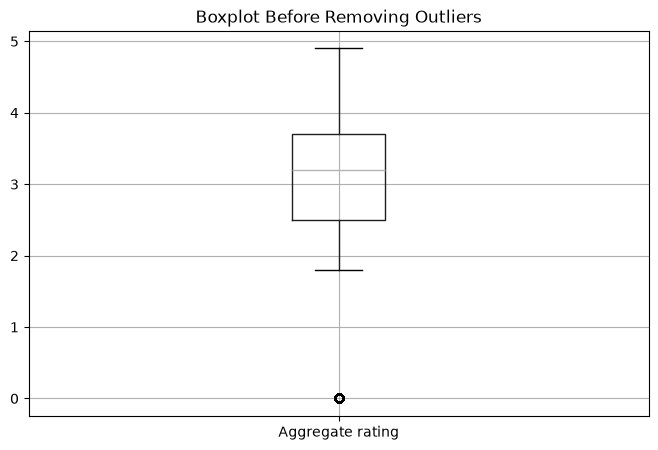

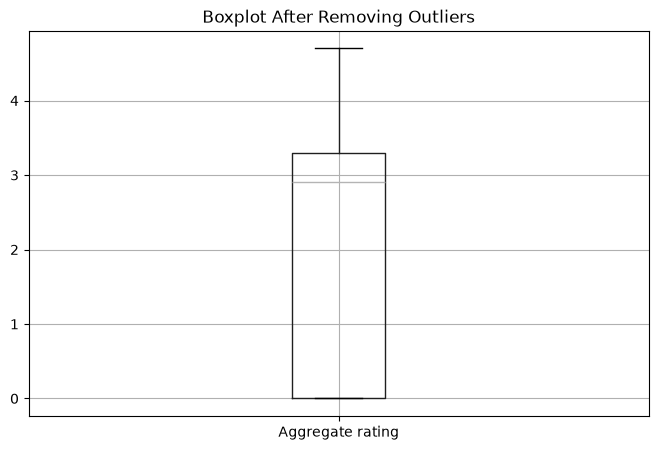

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
zomato_data.boxplot(column='Aggregate rating')
plt.title("Boxplot Before Removing Outliers")
plt.show()

plt.figure(figsize=(8,5))
zomato_no_outliers.boxplot(column='Aggregate rating')
plt.title("Boxplot After Removing Outliers")
plt.show()

In [10]:
zomato_data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


Mean Squared Error: 0.08561152314220585
R-squared: 0.962386896450611


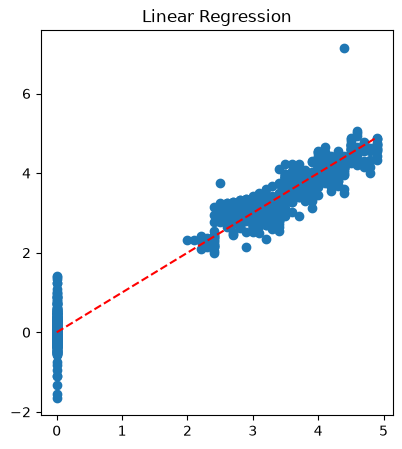

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

zomato_data = pd.read_csv(r"C:\Users\ArifAmeerJohn\Downloads\zomato.csv", encoding='latin-1')

text_features = (
    zomato_data.select_dtypes(include='str')
    .fillna('')
    .astype(str)
    .apply(lambda row: ' '.join(row), axis=1)
)

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(text_features)

y = pd.to_numeric(zomato_data['Aggregate rating'], errors='coerce').fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Linear Regression')

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

In [36]:
cuisine_df.head()

,Restaurant Id,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table Booking,Has Online Delivery,Is Delivering Now,Switch To Order Menu,Price Range,Aggregate Rating,Rating Color,Rating Text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,French,...,Botswana Pula(P),1,0,0,No,3,4.8,Dark Green,Excellent,314
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,Japanese,...,Botswana Pula(P),1,0,0,No,3,4.8,Dark Green,Excellent,314
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,Desserts,...,Botswana Pula(P),1,0,0,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),1,0,0,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,Seafood,...,Botswana Pula(P),1,0,0,No,4,4.4,Green,Very Good,270


In [37]:
zomato_data.head()

,Restaurant Id,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table Booking,Has Online Delivery,Is Delivering Now,Switch To Order Menu,Price Range,Aggregate Rating,Rating Color,Rating Text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),1,0,0,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),1,0,0,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),1,0,0,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, Sm Megamall, O...","Sm Megamall, Ortigas, Mandaluyong City","Sm Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),0,0,0,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, Sm Megamall, Ortigas...","Sm Megamall, Ortigas, Mandaluyong City","Sm Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),1,0,0,No,4,4.8,Dark Green,Excellent,229


In [38]:
cuisine_df.duplicated().sum()

np.int64(5)

Lasso (L1) MSE: 0.08451596323346268
Ridge (L2) MSE: 0.08586141940862704


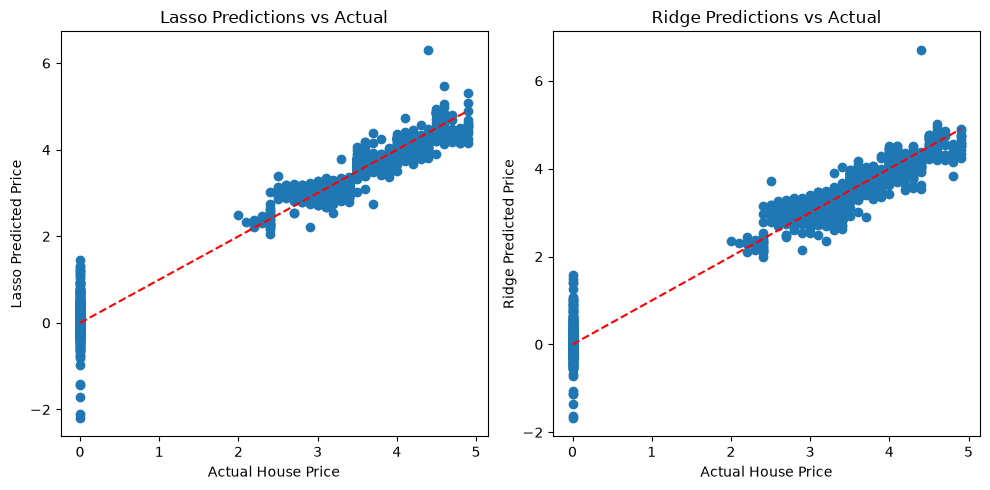

In [5]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer

zomato_data = pd.read_csv(r"C:\Users\ArifAmeerJohn\Downloads\zomato.csv", encoding='latin-1')

text_features = (
    zomato_data.select_dtypes(include='str')
    .fillna('')
    .astype(str)
    .apply(lambda row: ' '.join(row), axis=1)
)

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(text_features)

y = pd.to_numeric(zomato_data['Aggregate rating'], errors='coerce').fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models with regularization
lasso = Lasso(alpha=0.0001)  # L1 regularization (Lasso)
ridge = Ridge(alpha=0.1)  # L2 regularization (Ridge)

# Fit the models
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Predict on the test set
lasso_preds = lasso.predict(X_test)
ridge_preds = ridge.predict(X_test)

# Calculate Mean Squared Error
lasso_mse = mean_squared_error(y_test, lasso_preds)
ridge_mse = mean_squared_error(y_test, ridge_preds)

# Print results
print("Lasso (L1) MSE:", lasso_mse)
print("Ridge (L2) MSE:", ridge_mse)

# Plot the predictions
plt.figure(figsize=(10, 5))

# Actual vs Lasso Predictions
plt.subplot(1, 2, 1)
plt.scatter(y_test, lasso_preds)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Lasso Predictions vs Actual')
plt.xlabel('Actual House Price')
plt.ylabel('Lasso Predicted Price')

# Actual vs Ridge Predictions
plt.subplot(1, 2, 2)
plt.scatter(y_test, ridge_preds)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Ridge Predictions vs Actual')
plt.xlabel('Actual House Price')
plt.ylabel('Ridge Predicted Price')

plt.tight_layout()
plt.show()

In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense

# Load the California Housing Dataset
california = fetch_california_housing()
X = california.data  # Features
y = california.target  # Target (median house value)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for ANN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the ANN model
model = Sequential()

# Input layer (input shape should match the number of features in X)
model.add(Dense(units=10, activation='relu', input_dim=X_train.shape[1]))

# Hidden layer
model.add(Dense(units=5, activation='relu'))
#ReLU(z)=max(0,z)

# Output layer (since we're predicting a continuous value, no activation function)
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1)

# Evaluate the model
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Mean Squared Error on Test Set: {loss}")

# Predict house prices
y_pred = model.predict(X_test)

# Display predictions for the first 5 houses in the test set
print("Predicted prices: ", y_pred[:5])

ModuleNotFoundError: No module named 'tensorflow'